# División de datos (train/test) — kajve
### Paso 6 del pipeline de ML

Este notebook aplica y visualiza la división de datos definida en `ML/division_datos.py`, sobre
el dataset con features del paso 5 (`data/processed/lecturas_reales_features.csv`).

**Por qué no un `train_test_split` aleatorio de filas:**
1. **Fuga entre lecturas del mismo lote.** El paso 5 agregó columnas de ventana móvil
   (`temp_grano_media_1h`, etc.) que promedian lecturas vecinas — dos filas a segundos de
   distancia comparten información. Un split aleatorio de filas pondría lecturas casi idénticas
   en train y en test, inflando artificialmente cualquier métrica.
2. **Fuga entre lotes.** Si un mismo lote aporta filas a train y a test, el modelo puede
   memorizar el microclima/sensor de ESE lote en vez de generalizar. El estándar correcto es que
   cada lote completo vaya solo a un lado (`GroupShuffleSplit` por `id_lote`).

**El problema real de esta etapa del piloto:** hoy existe **un solo lote real con volumen
utilizable** (`id_lote=12`, ver pasos 3-5). Con un solo grupo, dividir por lote es matemáticamente
imposible — no se puede partir 1 grupo en 2 grupos no vacíos. Por eso `ML/division_datos.py`
implementa dos métodos y elige automáticamente:

- `group_shuffle_split_por_lote`: el método correcto/definitivo, listo para cuando existan >= 2
  lotes reales.
- `temporal_por_lote` (el que se usa HOY): dentro de cada lote, separa el tramo cronológico más
  reciente como test — permite evaluar honestamente "qué tan bien generaliza el modelo a horas de
  secado que no vio en entrenamiento", sin caer en la fuga del punto 1 (nunca se intercalan filas
  al azar dentro del mismo tramo de tiempo).


In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from ML import division_datos as dd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Carga del dataset con features (paso 5)

In [2]:
RUTA_FEATURES = "../data/processed/lecturas_reales_features.csv"
df = pd.read_csv(RUTA_FEATURES, parse_dates=["timestamp"])
print(f"Filas: {len(df):,}  |  Lotes: {df['id_lote'].nunique()}  |  Columnas: {len(df.columns)}")
df["id_lote"].value_counts()


Filas: 7,458  |  Lotes: 1  |  Columnas: 31


id_lote
12    7458
Name: count, dtype: int64

## 2. Aplicar la división de datos

In [3]:
df_train, df_test, info = dd.dividir_datos(df)
info


{'metodo': 'temporal_por_lote',
 'n_lotes': 1,
 'min_lotes_para_grupo': 2,
 'n_train': 5594,
 'n_test': 1864,
 'lotes_train': [12],
 'lotes_test': [12]}

**Lectura:** con `n_lotes=1`, `dividir_datos()` eligió automáticamente el método
`temporal_por_lote` (no hay forma de aplicar `group_shuffle_split_por_lote` con un solo grupo). El
mismo lote aparece tanto en `lotes_train` como en `lotes_test` — esperado y correcto para este
método: lo que se separa es el TIEMPO dentro del lote, no el lote en sí.

In [4]:
print(f"Train: {len(df_train):,} filas  ({df_train['timestamp'].min()} -> {df_train['timestamp'].max()})")
print(f"Test:  {len(df_test):,} filas  ({df_test['timestamp'].min()} -> {df_test['timestamp'].max()})")
print(f"Proporción test: {len(df_test) / len(df):.1%}")


Train: 5,594 filas  (2026-07-19 06:57:52.914814 -> 2026-07-20 08:45:44.768439)
Test:  1,864 filas  (2026-07-20 08:45:46.126348 -> 2026-07-20 15:07:05.694680)
Proporción test: 25.0%


## 3. Visualización del corte temporal

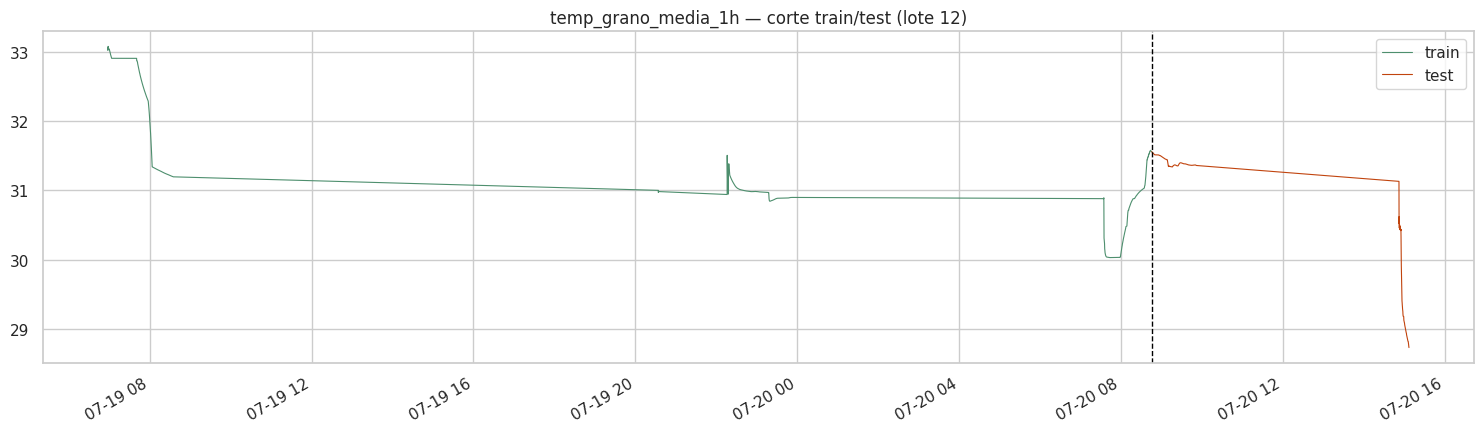

In [5]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(df_train["timestamp"], df_train["temp_grano_media_1h"], color="#4e8f6e", linewidth=0.8, label="train")
ax.plot(df_test["timestamp"], df_test["temp_grano_media_1h"], color="#c1440e", linewidth=0.8, label="test")
ax.axvline(df_test["timestamp"].min(), color="black", linestyle="--", linewidth=1)
ax.set_title("temp_grano_media_1h — corte train/test (lote 12)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


**Lectura:** el corte es limpio y cronológico — no hay entrelazado de puntos de train y test
en el tiempo, que es justo lo que evita la fuga por ventana móvil.

## 4. Sanity check: ¿train y test se parecen lo suficiente?

Con un split temporal (no aleatorio), vale la pena verificar que el tramo de test no sea
radicalmente distinto al de train en las variables clave — si el proceso de secado cambió mucho
de fase (p.ej. de "recién iniciado" a "casi terminado"), es normal ver diferencias, pero es
importante dejarlas documentadas en vez de asumir que "train y test son iguales".

In [6]:
comparacion = pd.DataFrame({
    "train": df_train[["temperatura_grano", "temperatura_ambiental", "luz", "progreso_proceso"]].mean(),
    "test": df_test[["temperatura_grano", "temperatura_ambiental", "luz", "progreso_proceso"]].mean(),
})
comparacion["diferencia"] = comparacion["test"] - comparacion["train"]
comparacion


,train,test,diferencia
temperatura_grano,31.246652,30.557108,-0.689543
temperatura_ambiental,26.446732,26.166196,-0.280536
luz,127.716621,10.194517,-117.522104
progreso_proceso,0.085830,0.167931,0.082101


In [7]:
print("Distribución de _severidad — train:")
print(df_train["_severidad"].value_counts(normalize=True).round(3))
print()
print("Distribución de _severidad — test:")
print(df_test["_severidad"].value_counts(normalize=True).round(3))


Distribución de _severidad — train:
_severidad
normal         0.996
critico        0.003
advertencia    0.001
Name: proportion, dtype: float64

Distribución de _severidad — test:
_severidad
normal     0.971
critico    0.029
Name: proportion, dtype: float64


**Lectura:** `progreso_proceso` en test es, por construcción, más alto que en train (test es
el tramo más reciente del secado) — es esperado y correcto, no un error. Si la distribución de
`_severidad` en test resulta muy distinta a la de train (p.ej. cero anomalías en uno de los dos
lados), es una limitación real a documentar al reportar métricas del paso 7, no algo que este
notebook pueda "arreglar" con un solo lote disponible.

## 5. Cuándo pasará a `group_shuffle_split_por_lote`

In [8]:
# Simulación ilustrativa: qué pasaría si ya existieran 3 lotes con volumen suficiente.
# (No se ejecuta sobre datos reales todavía -- es solo para dejar visible que el código
# ya está listo y no requiere cambios cuando el piloto crezca.)
import numpy as np

df_simulado = df.copy()
terceras = np.array_split(df_simulado.index, 3)
for nuevo_id, idx in zip([101, 102, 103], terceras):
    df_simulado.loc[idx, "id_lote"] = nuevo_id

_, _, info_simulado = dd.dividir_datos(df_simulado)
info_simulado


{'metodo': 'group_shuffle_split_por_lote',
 'n_lotes': 3,
 'min_lotes_para_grupo': 2,
 'n_train': 4972,
 'n_test': 2486,
 'lotes_train': [102, 103],
 'lotes_test': [101]}

**Lectura:** con >= 2 lotes, `dividir_datos()` cambia automáticamente a
`group_shuffle_split_por_lote` sin ningún cambio de código — cada lote completo cae solo en un
lado. Este bloque usa un id_lote simulado únicamente para demostrarlo; no se usa en la salida
real que se exporta abajo.

## 6. Exportar train/test (listos para el paso 7: entrenamiento)

In [9]:
os.makedirs("../data/processed", exist_ok=True)
RUTA_TRAIN = "../data/processed/train.csv"
RUTA_TEST = "../data/processed/test.csv"
df_train.to_csv(RUTA_TRAIN, index=False)
df_test.to_csv(RUTA_TEST, index=False)
print(f"Guardado: {RUTA_TRAIN}  ({len(df_train):,} filas)")
print(f"Guardado: {RUTA_TEST}  ({len(df_test):,} filas)")


Guardado: ../data/processed/train.csv  (5,594 filas)
Guardado: ../data/processed/test.csv  (1,864 filas)


## 7. Conclusiones y siguiente paso

- Con un solo lote real de volumen, la división de datos usa un corte **cronológico dentro del
  lote** (`temporal_por_lote`), no un split aleatorio de filas ni un split por grupo — ambos
  imposibles o inseguros en esta etapa.
- El código para el método correcto a largo plazo (`group_shuffle_split_por_lote`) ya está
  implementado y se activa solo cuando existan >= 2 lotes reales con volumen suficiente — no hará
  falta tocar `division_datos.py` cuando eso pase.
- `scripts/train_models.py` implementa hoy su propio `GroupShuffleSplit` inline en cada función
  de entrenamiento (`entrenar_clasificador_tipo/tiempo/calidad`), sin el fallback temporal de este
  módulo — con el único lote real actual, eso hace que esas funciones se salten por completo (ver
  su propio guard de "menos de 2 lotes"). Adoptar `ML/division_datos.py` ahí permitiría evaluar
  `rf_tipo_anomalia` (que no depende de lotes finalizados) incluso con un solo lote real, en vez
  de esperar a que existan más.
- **Siguiente paso natural:** paso 7, entrenar los modelos sobre `data/processed/train.csv` y
  evaluar sobre `data/processed/test.csv`.
